                 INPUT SENTENCE
                       │
                       ▼
            "I love this product"
                       │
                       ▼
                  TOKENIZER
                       │
                       ▼
             Integer Token IDs
             [2, 5, 8, 12]
                       │
                       ▼
                  PADDING
                       │
                       ▼
            [2, 5, 8, 12, 0, 0]
                       │
                       ▼
                 EMBEDDING
                       │
                       ▼
          Word Embedding Vectors
                       │
                       ▼
                 ┌───────────┐
                 │  SIMPLE   │
                 │    RNN    │
                 └───────────┘
                       │
            ┌──────────┼──────────┐
            ▼          ▼          ▼
           h₁         h₂         h₃  ... hₜ
            │          │          │
            └──────────┴──────────┘
                       │
                       ▼
              FINAL HIDDEN STATE
                       │
                       ▼
                  DENSE LAYER
                       │
                       ▼
                  SIGMOID (0-1)
                       │
                       ▼
              ┌────────┴────────┐
              ▼                 ▼
          Positive            Negative
             1                   0

In [3]:
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

In [6]:
sentences = [
    "I love this product",
    "This movie made me smile",
    "Service was friendly and quick",
    "Today felt bright and happy",
    "This is the best day",
    "Absolutely fantastic experience",
    "I enjoyed every single moment",
    "Great job well done",
    "The food tasted delicious",
    "Totally recommend to everyone",
    "Very satisfied with results",
    "This worked better than expected",
    "Amazing quality and value",
    "Such a pleasant surprise",
    "I feel positive about this",
    "I hate this product",
    "This movie was extremely boring",
    "The service was slow and terrible",
    "Today was a disappointing day",
    "This is the worst experience",
    "I regret buying this product",
    "Nothing worked as expected",
    "The food tasted awful",
    "I would not recommend this",
    "Very unhappy with the results",
    "The quality was extremely poor",
    "This was a complete waste",
    "I had a terrible experience",
    "The product stopped working",
    "I am disappointed with everything"
]
labels=[1]*15+[0]*15
labels=np.array(labels)


In [7]:
vocab_size = 2000

tok = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tok.fit_on_texts(sentences)

seq = tok.texts_to_sequences(sentences)

maxlen = max(len(s) for s in seq)

X = pad_sequences(
    seq,
    maxlen=maxlen,
    padding="post"
)

6

In [11]:
X[24]

array([19, 73, 10,  4, 20,  0], dtype=int32)

In [12]:
embed_dim=16
rnn_units=8


In [13]:
inp=Input(shape=(maxlen,),dtype="int32",name="input")

In [15]:
inp = Input(shape=(maxlen,), name="input")

x = Embedding(
    input_dim=vocab_size,
    output_dim=embed_dim,
    mask_zero=True,
    name="embed"
)(inp)

rnn = SimpleRNN(
    units=rnn_units,
    return_sequences=False,
    return_state=False,
    name="simple_rnn"
)

x_last = rnn(x)

out = Dense(
    1,
    activation="sigmoid",
    name="out"
)(x_last)

model = Model(
    inputs=inp,
    outputs=out
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 6, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 6)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 8)         │        200 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │          9 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,209 (125.82 KB)

 Trainable params: 32,209 (125.82 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.fit(
    X,
    labels,
    epochs=25,
    batch_size=8,
    verbose=1
)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.3667 - loss: 0.7021
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5667 - loss: 0.6845
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7667 - loss: 0.6707
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8333 - loss: 0.6565 
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8667 - loss: 0.6421 
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9000 - loss: 0.6267 
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9333 - loss: 0.6121 
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9667 - loss: 0.5957 
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9667 - loss: 0.5781 
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9667 - loss: 0.5597 
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9667 - loss: 0.5402 
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9667 - loss: 0.5196


Vocabulary size: 82
Maximum sequence length: 6
X shape: (30, 6)
y shape: (30,)


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 6)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 6, 16)     │     32,000 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 6)         │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 16)        │        528 │ embed[0][0],      │
│ (SimpleRNN)         │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │         17 │ simple_rnn[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 32,545 (127.13 KB)

 Trainable params: 32,545 (127.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5333 - loss: 0.7002
Epoch 2/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7333 - loss: 0.6852
Epoch 3/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7333 - loss: 0.6737
Epoch 4/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8333 - loss: 0.6619 
Epoch 5/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8667 - loss: 0.6505 
Epoch 6/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8667 - loss: 0.6370
Epoch 7/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9000 - loss: 0.6234 
Epoch 8/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9000 - loss: 0.6072 
Epoch 9/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9000 - loss: 0.5888 
Epoch 10/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9000 - loss: 0.5687 
Epoch 11/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9333 - loss: 0.5461
Epoch 12/25
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9333 - loss: 0.5218 
E

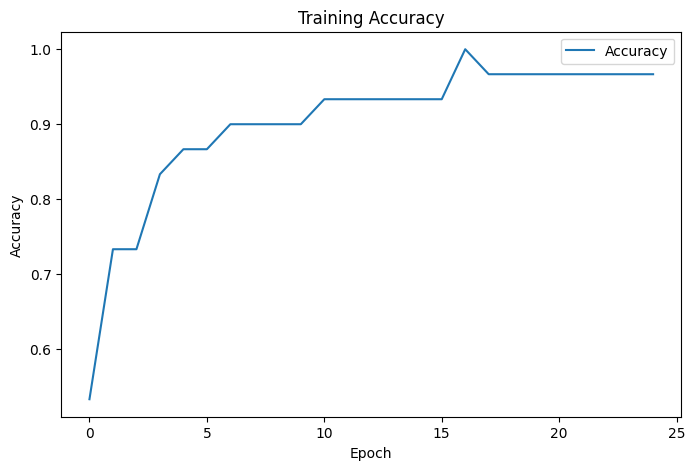


Selected sentence:
I love this product

Timesteps:
t1: I
t2: love
t3: this
t4: product
t5: PAD
t6: PAD

Hidden state shape:
(6, 16)


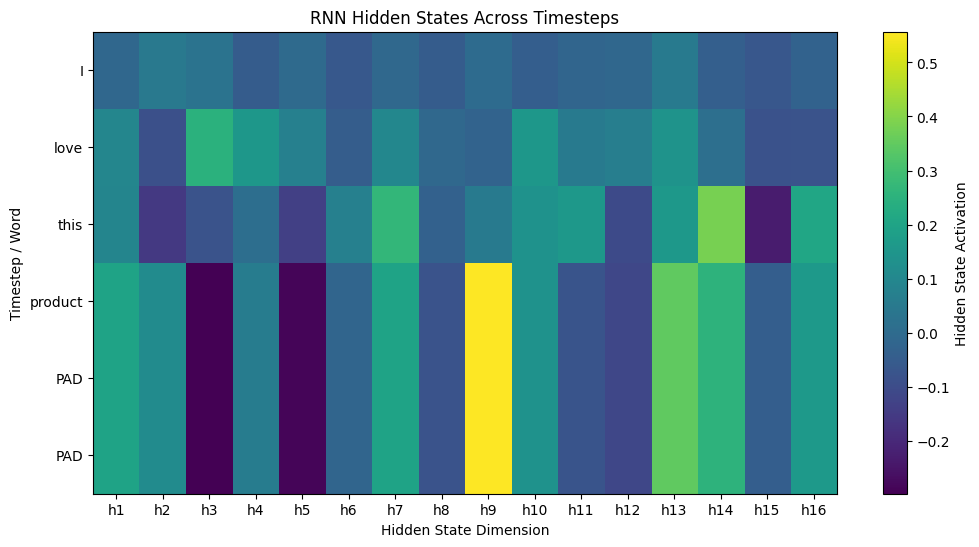

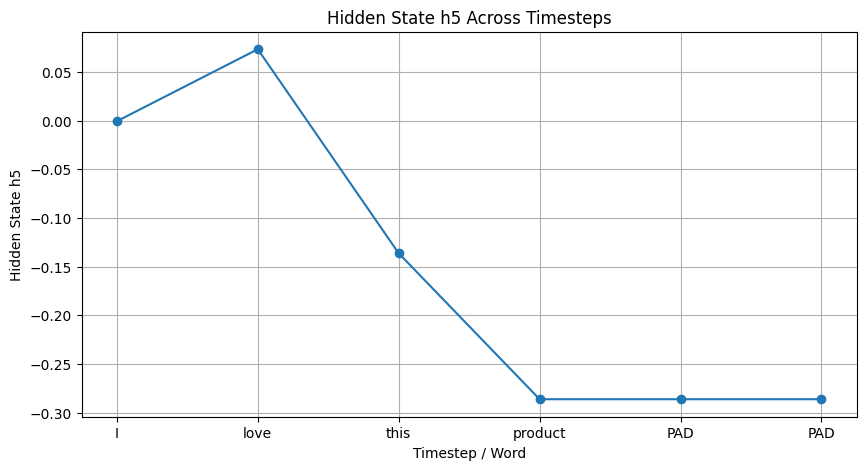


Prediction probability: 0.7669265
Prediction: POSITIVE


In [21]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense


# ============================================================
# 1. DATASET
# ============================================================

sentences = [
    "I love this product",
    "This movie made me smile",
    "Service was friendly and quick",
    "Today felt bright and happy",
    "This is the best day",
    "Absolutely fantastic experience",
    "I enjoyed every single moment",
    "Great job well done",
    "The food tasted delicious",
    "Totally recommend to everyone",
    "Very satisfied with results",
    "This worked better than expected",
    "Amazing quality and value",
    "Such a pleasant surprise",
    "I feel positive about this",

    "I hate this product",
    "This movie was extremely boring",
    "The service was slow and terrible",
    "Today was a disappointing day",
    "This is the worst experience",
    "I regret buying this product",
    "Nothing worked as expected",
    "The food tasted awful",
    "I would not recommend this",
    "Very unhappy with the results",
    "The quality was extremely poor",
    "This was a complete waste",
    "I had a terrible experience",
    "The product stopped working",
    "I am disappointed with everything"
]


# 1 = Positive
# 0 = Negative

labels = np.array([
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,
    1, 1, 1, 1, 1,

    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0,
    0, 0, 0, 0, 0
])


# ============================================================
# 2. TOKENIZATION
# ============================================================

vocab_size = 2000

tok = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tok.fit_on_texts(sentences)

seq = tok.texts_to_sequences(sentences)

maxlen = max(len(s) for s in seq)

X = pad_sequences(
    seq,
    maxlen=maxlen,
    padding="post"
)

y = labels


print("Vocabulary size:", len(tok.word_index))
print("Maximum sequence length:", maxlen)
print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. MODEL PARAMETERS
# ============================================================

embed_dim = 16
rnn_units = 16


# ============================================================
# 4. BUILD RNN MODEL
# ============================================================

inp = Input(
    shape=(maxlen,),
    name="input"
)

x = Embedding(
    input_dim=vocab_size,
    output_dim=embed_dim,
    mask_zero=True,
    name="embed"
)(inp)

rnn = SimpleRNN(
    units=rnn_units,
    return_sequences=False,
    return_state=False,
    name="simple_rnn"
)

x_last = rnn(x)

out = Dense(
    1,
    activation="sigmoid",
    name="out"
)(x_last)

model = Model(
    inputs=inp,
    outputs=out
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


# ============================================================
# 5. TRAIN MODEL
# ============================================================

history = model.fit(
    X,
    y,
    epochs=25,
    batch_size=8,
    verbose=1
)


# ============================================================
# 6. TRAINING PERFORMANCE
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.legend()

plt.show()


# ============================================================
# 7. CREATE MODEL TO EXTRACT HIDDEN STATES
# ============================================================

# IMPORTANT:
# We are using the SAME trained RNN layer.
# We create a model that gives us the output of the
# trained RNN at every timestep.

embedding_layer = model.get_layer("embed")
trained_rnn = model.get_layer("simple_rnn")

vis_input = model.input

embedding_output = embedding_layer(vis_input)

# We need a new RNN configuration that returns sequences.
# To preserve the trained weights, create the layer and
# copy the trained weights.

rnn_for_visualization = SimpleRNN(
    units=rnn_units,
    return_sequences=True,
    name="rnn_visualization"
)

hidden_output = rnn_for_visualization(embedding_output)

# Copy weights from trained RNN
rnn_for_visualization.set_weights(
    trained_rnn.get_weights()
)

vis_model = Model(
    inputs=vis_input,
    outputs=hidden_output
)


# ============================================================
# 8. SELECT ONE SENTENCE
# ============================================================

sentence_index = 0

selected_sentence = sentences[sentence_index]

print("\nSelected sentence:")
print(selected_sentence)


# ============================================================
# 9. GET WORDS / TIMESTEPS
# ============================================================

words = selected_sentence.split()

display_words = words + ["PAD"] * (
    maxlen - len(words)
)

print("\nTimesteps:")

for i, word in enumerate(display_words):
    print(f"t{i + 1}: {word}")


# ============================================================
# 10. GET HIDDEN STATES
# ============================================================

hidden_states = vis_model.predict(
    X[sentence_index:sentence_index + 1],
    verbose=0
)

# Remove batch dimension
hidden_states = hidden_states[0]

print("\nHidden state shape:")
print(hidden_states.shape)


# Expected:
#
# (maxlen, rnn_units)
#
# Example:
#
# (6, 16)


# ============================================================
# 11. HIDDEN STATE HEATMAP
# ============================================================

plt.figure(figsize=(12, 6))

plt.imshow(
    hidden_states,
    aspect="auto"
)

plt.colorbar(
    label="Hidden State Activation"
)

plt.xticks(
    range(rnn_units),
    [f"h{i + 1}" for i in range(rnn_units)]
)

plt.yticks(
    range(maxlen),
    display_words
)

plt.xlabel("Hidden State Dimension")
plt.ylabel("Timestep / Word")

plt.title(
    "RNN Hidden States Across Timesteps"
)

plt.show()


# ============================================================
# 12. VISUALIZE ONE HIDDEN NEURON
# ============================================================

hidden_dim = 4

plt.figure(figsize=(10, 5))

plt.plot(
    range(maxlen),
    hidden_states[:, hidden_dim],
    marker="o"
)

plt.xticks(
    range(maxlen),
    display_words
)

plt.xlabel("Timestep / Word")

plt.ylabel(
    f"Hidden State h{hidden_dim + 1}"
)

plt.title(
    f"Hidden State h{hidden_dim + 1} Across Timesteps"
)

plt.grid(True)

plt.show()


# ============================================================
# 13. PREDICT THE SENTENCE
# ============================================================

prediction = model.predict(
    X[sentence_index:sentence_index + 1],
    verbose=0
)[0][0]

print("\nPrediction probability:", prediction)

if prediction >= 0.5:
    print("Prediction: POSITIVE")
else:
    print("Prediction: NEGATIVE")

In [22]:
test_sentences = [
    "I absolutely love this",
    "This product is amazing",
    "The experience was wonderful",
    "I really enjoyed it",
    "This is fantastic",

    "I absolutely hate this",
    "This product is terrible",
    "The experience was horrible",
    "I really disliked it",
    "This is disappointing"
]

test_seq = tok.texts_to_sequences(test_sentences)

X_test = pad_sequences(
    test_seq,
    maxlen=maxlen,
    padding="post"
)

print(X_test)
print(X_test.shape)

[[ 3 36 26  2  0  0]
 [ 2  6 14 53  0  0]
 [ 4  9  5  1  0  0]
 [ 3  1 38  1  0  0]
 [ 2 14 37  0  0  0]
 [ 3 36 61  2  0  0]
 [ 2  6 14 25  0  0]
 [ 4  9  5  1  0  0]
 [ 3  1  1  1  0  0]
 [ 2 14 64  0  0  0]]
(10, 6)


In [23]:
predictions = model.predict(X_test)

for sentence, prediction in zip(test_sentences, predictions):
    sentiment = "POSITIVE" if prediction[0] >= 0.5 else "NEGATIVE"

    print(
        f"{sentence:35} → "
        f"{sentiment} ({prediction[0]:.3f})"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
I absolutely love this              → POSITIVE (0.855)
This product is amazing             → NEGATIVE (0.322)
The experience was wonderful        → NEGATIVE (0.211)
I really enjoyed it                 → NEGATIVE (0.494)
This is fantastic                   → POSITIVE (0.567)
I absolutely hate this              → POSITIVE (0.719)
This product is terrible            → NEGATIVE (0.257)
The experience was horrible         → NEGATIVE (0.211)
I really disliked it                → NEGATIVE (0.315)
This is disappointing               → POSITIVE (0.585)


                 INPUT SEQUENCE
                       │
                       ▼
                Preprocessing
                       │
                       ▼
                 Tokenization
                       │
                       ▼
                  Embedding
                       │
                       ▼
              ┌─────────────────┐
              │      RNN        │
              │                 │
              │  x₁ → h₁        │
              │  x₂ → h₂        │
              │  x₃ → h₃        │
              │  ...            │
              │  xₜ → hₜ        │
              └────────┬────────┘
                       │
             Hidden States / Output
                       │
                       ▼
                 Output Layer
                       │
                       ▼
                  Prediction